## **Notebook 3: Machine Learning Model**


**1. Introduction**

In this notebook, we:

* Define the ML problem
* Prepare data
* Train and test a model
* Evaluate performance

**2. Problem Statement**

**Objective:**

To classify iris flowers into species based on their features.

**Type of ML Problem:**
* Supervised Learning
* Classification Problem
* Target Variable:
 `Species`

**3. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression

**4. Load Dataset**

In [ ]:
import seaborn as sns
import pandas as pd

# Load dataset
df = sns.load_dataset('iris')

# Rename columns (same as your project)
df.rename(columns={
    'sepal_length': 'SepalLength',
    'sepal_width': 'SepalWidth',
    'petal_length': 'PetalLength',
    'petal_width': 'PetalWidth',
    'species': 'Species'
}, inplace=True)

# Save file
df.to_csv('iris_cleaned.csv', index=False)

print("File created successfully!")

File created successfully!


In [ ]:
df = pd.read_csv('iris_cleaned.csv')
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**5 Data Preparation **:

Separate Features and Target

In [ ]:
X = df.drop('Species', axis=1)
y = df['Species']

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**6. Model Selection**

Chosen Model:

* Logistic Regression

Reason:

* Simple and effective for classification
* Works well for linearly separable data

**7. Model Training**

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

**8. Model Testing**

In [ ]:
y_pred = model.predict(X_test)

**9. Model Evaluation**

Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


**Observation**:

Accuracy is usually very high (~95%–100%)

**Conclusion:**
Model performs well on test data

##  **Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


**Visualization**

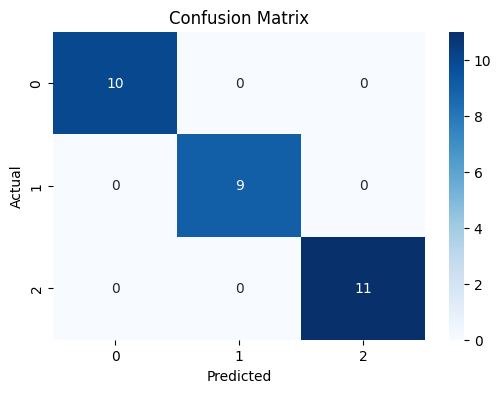

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observation:**
* Most predictions fall on diagonal → correct * classification

**Conclusion**:

Model has strong predictive performance

## **Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Observation:**

Precision, Recall, and F1-score are high for all classes

**Conclusion:**

Balanced performance across all species

## **10. Model Testing on New Data**


In [ ]:
# Example input
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)
print("Predicted class:", le.inverse_transform(prediction))

Predicted class: ['setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


11. ML Lifecycle Summary
Steps Completed:
 1) Problem Definition
 2) Data Collection (Notebook 1)
 3)  Cleaning & Wrangling
 4) EDA (Notebook 2)
5) Features Selection
6) model Selection
7) Model Training
8) Model Testing
9) Model Evaluation

# **Conclusion**
Logistic Regression achieved high accuracy
Petal features were most influential (as seen in EDA)
Dataset is well-structured and easy for classification